In [2]:
!pip install torch_geometric ogb -q

In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader
from torch_geometric.transforms import ToUndirected
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [4]:
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage

torch.serialization.add_safe_globals([DataEdgeAttr, DataTensorAttr, GlobalStorage])

dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    root='/kaggle/working/ogb_data',
    transform=ToUndirected()
)

data = dataset[0]
split_idx = dataset.get_idx_split()
data = data.to(device)

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features: {data.num_features}")
print(f"Classes: {dataset.num_classes}")

Nodes: 169343
Edges: 2315598
Features: 128
Classes: 40


In [5]:
import torch
print(torch.__version__)

2.10.0+cu128


In [6]:
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q

In [7]:
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q

In [8]:
!pip show torch-sparse
!pip show pyg-lib

Name: torch_sparse
Version: 0.6.18+pt210cu128
Summary: PyTorch Extension Library of Optimized Autograd Sparse Matrix Operations
Home-page: https://github.com/rusty1s/pytorch_sparse
Author: Matthias Fey
Author-email: matthias.fey@tu-dortmund.de
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: scipy
Required-by: 
Name: pyg_lib
Version: 0.6.0+pt210cu128
Summary: Low-Level Graph Neural Network Operators for PyG
Home-page: https://pyg.org
Author: 
Author-email: PyG Team <team@pyg.org>
License: Copyright (c) 2022 PyG Team <team@pyg.org>

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The abo

In [14]:
train_eval_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['train'],
    shuffle=False
)

val_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['valid']
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['test']
)

In [15]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.bns   = torch.nn.ModuleList()
        self.dropout = dropout

        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(torch.nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(torch.nn.BatchNorm1d(hidden_channels))

        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

model = GraphSAGE(
    in_channels=data.num_features,
    hidden_channels=256,
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.5
).to(device)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(128, 256, aggr=mean)
    (1): SAGEConv(256, 256, aggr=mean)
    (2): SAGEConv(256, 40, aggr=mean)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
Parameters: 218,664


In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
evaluator = Evaluator(name='ogbn-arxiv')

def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        out = out[:batch.batch_size]
        y   = batch.y[:batch.batch_size].squeeze()
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader, split_key):
    model.eval()
    preds = []
    for batch in loader:
        batch = batch.to(device)
        out  = model(batch.x, batch.edge_index)
        pred = out[:batch.batch_size].argmax(dim=-1, keepdim=True)
        preds.append(pred.cpu())
    preds  = torch.cat(preds, dim=0)
    y_true = data.y[split_idx[split_key]].cpu()
    return evaluator.eval({'y_true': y_true, 'y_pred': preds})['acc']

In [18]:
best_val_acc = 0
save_path = '/kaggle/working/graphsage_best.pt'

for epoch in range(1, 201):
    loss = train()

    if epoch % 10 == 0:
        train_acc = evaluate(train_eval_loader, 'train')
        val_acc   = evaluate(val_loader,   'valid')
        test_acc  = evaluate(test_loader,  'test')

        print(f'Epoch {epoch:03d} | Loss: {loss:.4f} | '
              f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'test_acc': test_acc,
            }, save_path)
            print(f'  New best model saved! Val: {val_acc:.4f}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch 010 | Loss: 0.8955 | Train: 0.7547 | Val: 0.7211 | Test: 0.7111
  New best model saved! Val: 0.7211
Epoch 020 | Loss: 0.8367 | Train: 0.7676 | Val: 0.7170 | Test: 0.6998
Epoch 030 | Loss: 0.8021 | Train: 0.7813 | Val: 0.7219 | Test: 0.7049
  New best model saved! Val: 0.7219
Epoch 040 | Loss: 0.7786 | Train: 0.7903 | Val: 0.7235 | Test: 0.7119
  New best model saved! Val: 0.7235
Epoch 050 | Loss: 0.7603 | Train: 0.7960 | Val: 0.7194 | Test: 0.7038
Epoch 060 | Loss: 0.7415 | Train: 0.8035 | Val: 0.7200 | Test: 0.6990
Epoch 070 | Loss: 0.7268 | Train: 0.8074 | Val: 0.7245 | Test: 0.7091
  New best model saved! Val: 0.7245
Epoch 080 | Loss: 0.7195 | Train: 0.8126 | Val: 0.7283 | Test: 0.7122
  New best model saved! Val: 0.7283
Epoch 090 | Loss: 0.7041 | Train: 0.8186 | Val: 0.7270 | Test: 0.7112
Epoch 100 | Loss: 0.6999 | Train: 0.8217 | Val: 0.7298 | Test: 0.7133
  New best model saved! Val: 0.7298
Epoch 110 | Loss: 0.6878 | Train: 0.8244 | Val: 0.7291 | Test: 0.7123
Epoch 120 | Lo

In [19]:
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])

final_test_acc = evaluate(test_loader, 'test')
print(f"Final Test Accuracy: {final_test_acc:.4f}")
print(f"Achieved at epoch: {checkpoint['epoch']}")

Final Test Accuracy: 0.7159
Achieved at epoch: 170


In [20]:
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']}")

Loaded best model from epoch 170


In [21]:
@torch.no_grad()
def get_predictions(loader):
    model.eval()
    preds = []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        pred = out[:batch.batch_size].argmax(dim=-1)
        preds.append(pred.cpu())
    return torch.cat(preds, dim=0)

test_preds = get_predictions(test_loader)
test_labels = data.y[split_idx['test']].cpu().squeeze()
print(f"Predictions: {test_preds.shape}, Labels: {test_labels.shape}")

Predictions: torch.Size([48603]), Labels: torch.Size([48603])


In [22]:
import numpy as np

num_classes = dataset.num_classes
per_class_acc = []
for c in range(num_classes):
    mask = test_labels == c
    if mask.sum() > 0:
        acc = (test_preds[mask] == test_labels[mask]).float().mean().item()
        per_class_acc.append((c, acc, mask.sum().item()))

per_class_acc.sort(key=lambda x: x[1], reverse=True)

print("Top 5 classes:")
for c, acc, count in per_class_acc[:5]:
    print(f"  Class {c}: {acc:.4f} ({count} samples)")

print("\nBottom 5 classes:")
for c, acc, count in per_class_acc[-5:]:
    print(f"  Class {c}: {acc:.4f} ({count} samples)")

Top 5 classes:
  Class 16: 0.9341 (10477 samples)
  Class 30: 0.9253 (4631 samples)
  Class 28: 0.9028 (2849 samples)
  Class 14: 0.7746 (71 samples)
  Class 25: 0.7579 (475 samples)

Bottom 5 classes:
  Class 29: 0.1167 (120 samples)
  Class 35: 0.0833 (36 samples)
  Class 11: 0.0795 (239 samples)
  Class 21: 0.0588 (51 samples)
  Class 12: 0.0000 (5 samples)


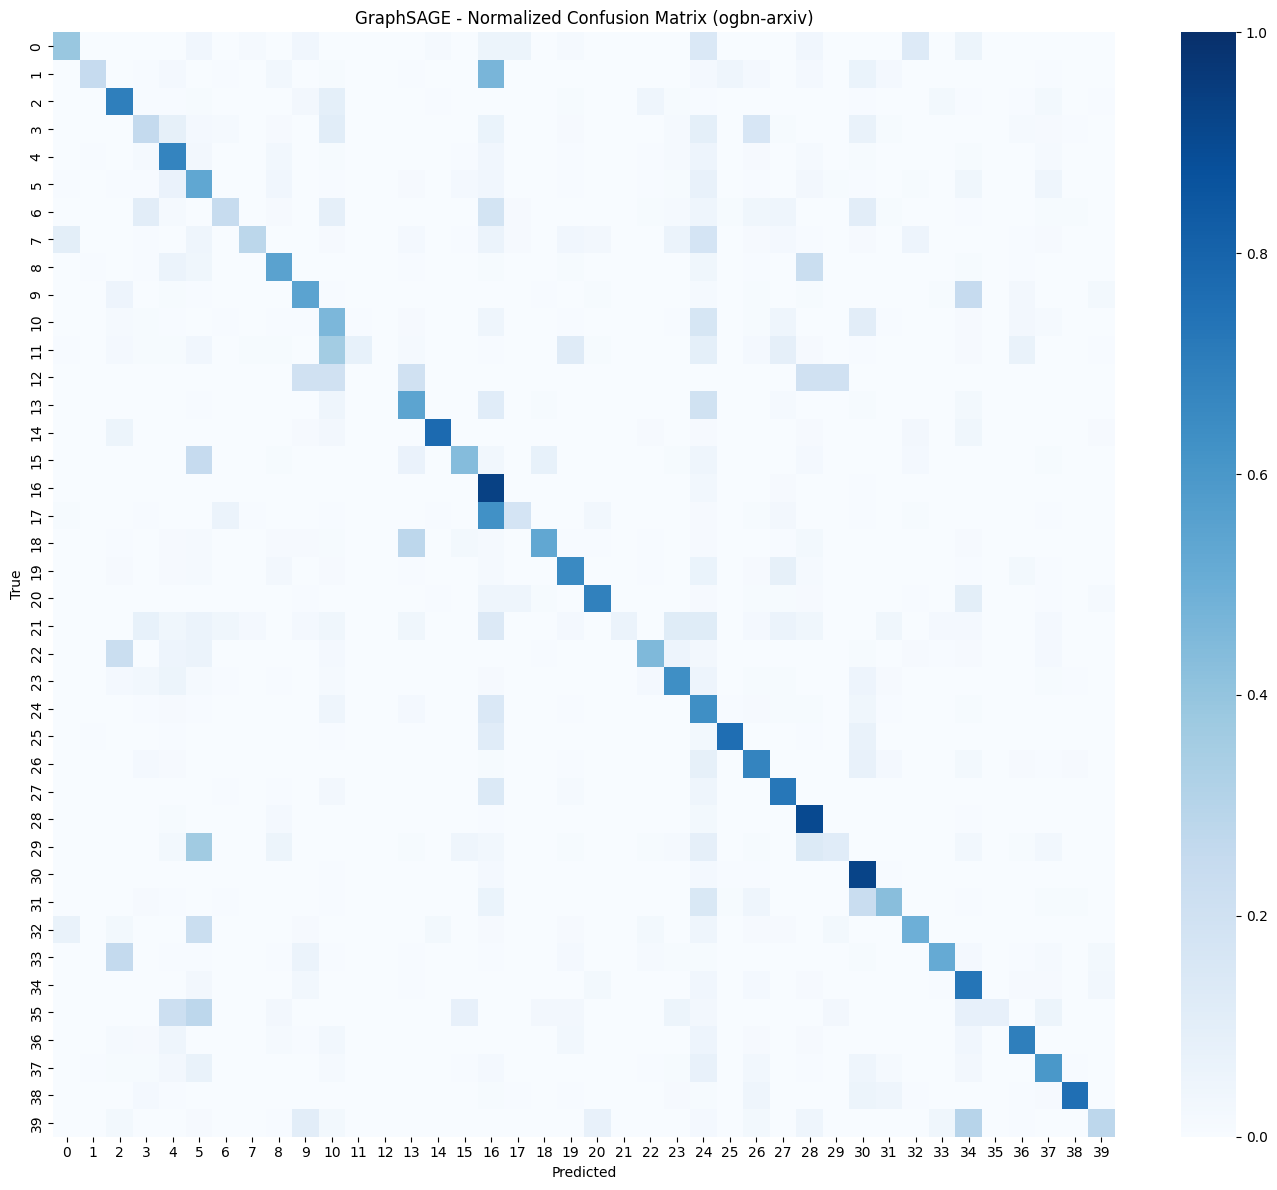

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy())
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_normalized, cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GraphSAGE - Normalized Confusion Matrix (ogbn-arxiv)')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

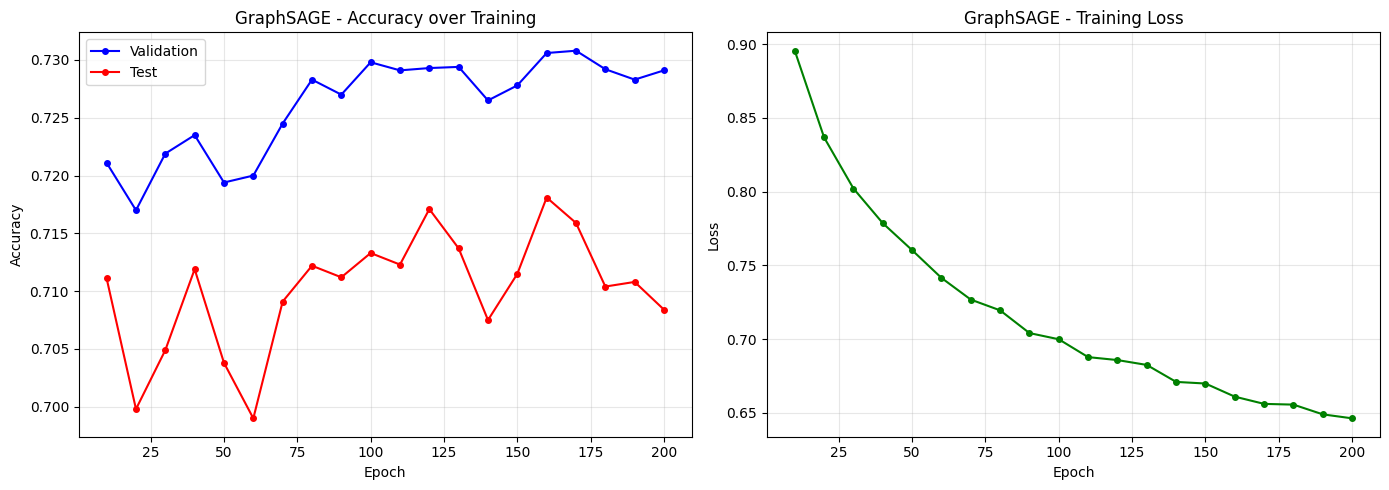

In [26]:
epochs_logged = list(range(10, 201, 10))

val_accs = [0.7211, 0.7170, 0.7219, 0.7235, 0.7194, 0.7200, 0.7245, 0.7283,
            0.7270, 0.7298, 0.7291, 0.7293, 0.7294, 0.7265, 0.7278, 0.7306,
            0.7308, 0.7292, 0.7283, 0.7291]

test_accs = [0.7111, 0.6998, 0.7049, 0.7119, 0.7038, 0.6990, 0.7091, 0.7122,
             0.7112, 0.7133, 0.7123, 0.7171, 0.7137, 0.7075, 0.7115, 0.7181,
             0.7159, 0.7104, 0.7108, 0.7084]

losses = [0.8955, 0.8367, 0.8021, 0.7786, 0.7603, 0.7415, 0.7268, 0.7195,
          0.7041, 0.6999, 0.6878, 0.6858, 0.6825, 0.6710, 0.6699, 0.6610,
          0.6561, 0.6556, 0.6490, 0.6463]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('GraphSAGE - Accuracy over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GraphSAGE - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

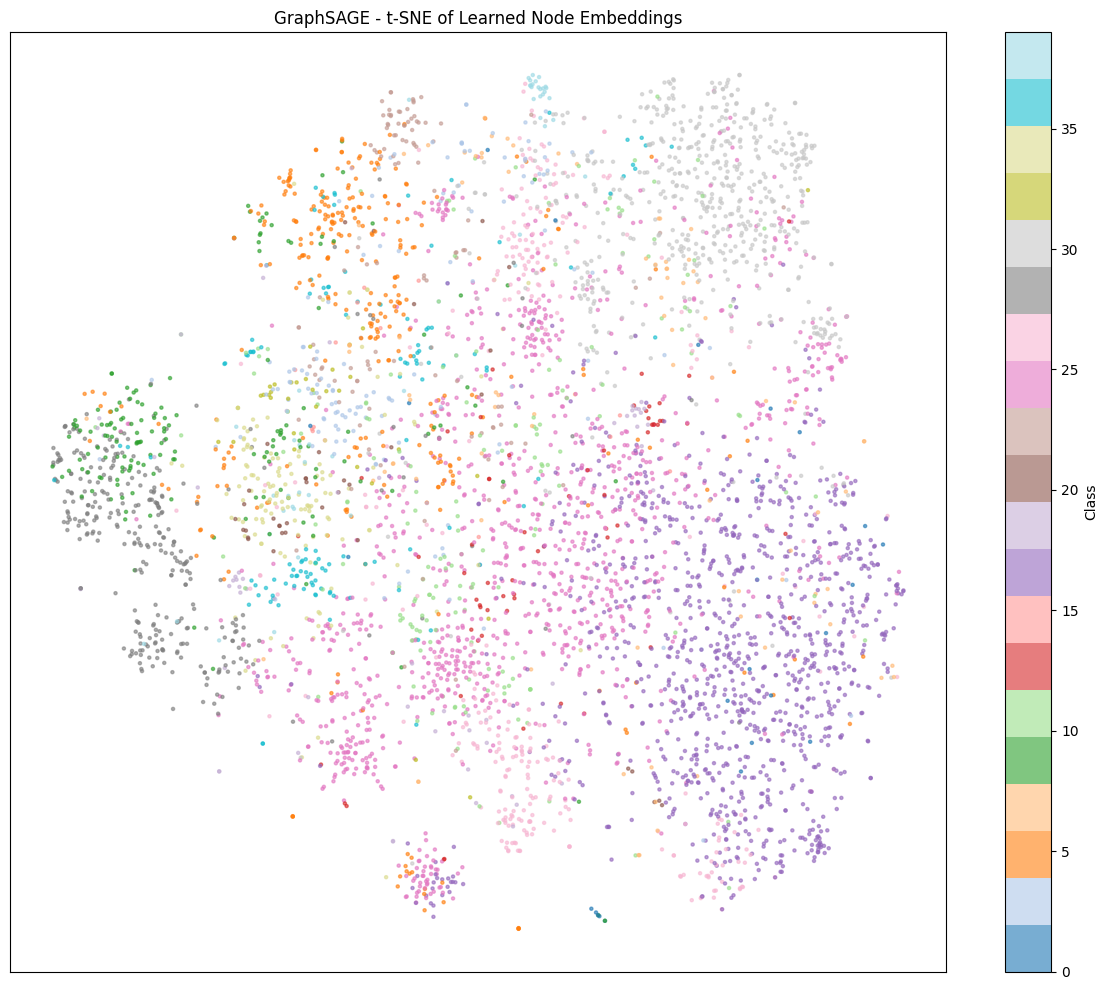

In [27]:
from sklearn.manifold import TSNE

@torch.no_grad()
def get_embeddings(loader):
    model.eval()
    embeds = []
    for batch in loader:
        batch = batch.to(device)
        # Get embeddings before final layer
        x = batch.x
        for i, conv in enumerate(model.convs[:-1]):
            x = conv(x, batch.edge_index)
            x = model.bns[i](x)
            x = F.relu(x)
        embeds.append(x[:batch.batch_size].cpu())
    return torch.cat(embeds, dim=0)

test_embeds = get_embeddings(test_loader)

# Subsample for speed (t-SNE is slow on full dataset)
n_samples = 5000
indices = np.random.choice(len(test_embeds), n_samples, replace=False)
embeds_sub = test_embeds[indices].numpy()
labels_sub = test_labels[indices].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeds_2d = tsne.fit_transform(embeds_sub)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(embeds_2d[:, 0], embeds_2d[:, 1], 
                     c=labels_sub, cmap='tab20', s=5, alpha=0.6)
ax.set_title('GraphSAGE - t-SNE of Learned Node Embeddings')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150)
plt.show()